# 🔬 Embryo Classification — CNN + LSTM
### Kaggle · `abhishekbuddiga06/embryo-dataset`

---

**Dataset:** 704 embryo time-lapse sequences · 342,363 images · 12 developmental grades (1–12)  
**Labels:** Extracted from annotation filenames: `AA83-7_phases.csv` → embryo `AA83-7` → Grade 7  
**Pipeline:** ResNet18 CNN (per-frame spatial features) → LSTM (temporal dynamics) → Grade classification

```
01 · Imports & Seed          07 · CNN + LSTM Model
02 · Paths & Config          08 · Training Loop
03 · Manifest Builder        09 · Training Curves
04 · Grade Grouping          10 · Test Evaluation
05 · Dataset Visualisation   11 · Confusion Matrix
06 · PyTorch Dataset/Loader  12 · Prediction Examples
                             13 · Export & Inference
```

## 01 · Imports & Seed

In [50]:
import os, json, re, random, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB


## 02 · Paths & Config

In [51]:
# ── Hardcoded exact paths (confirmed from directory inspection) ───
DATASET_ROOT = Path('/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset')
IMG_DIR      = DATASET_ROOT / 'embryo_dataset' / 'embryo_dataset'
ANN_DIR      = DATASET_ROOT / 'embryo_dataset_annotations' / 'embryo_dataset_annotations'

assert IMG_DIR.exists(), f'IMG_DIR not found: {IMG_DIR}'
assert ANN_DIR.exists(), f'ANN_DIR not found: {ANN_DIR}'
print(f'IMG_DIR : {IMG_DIR}  exists=True')
print(f'ANN_DIR : {ANN_DIR}  exists=True')
print(f'Embryo folders : {sum(1 for p in IMG_DIR.iterdir() if p.is_dir())}')
print(f'Ann files      : {sum(1 for p in ANN_DIR.iterdir() if p.suffix == ".csv")}')

OUT_DIR  = Path('/kaggle/working/outputs');     OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR = Path('/kaggle/working/checkpoints'); CKPT_DIR.mkdir(parents=True, exist_ok=True)

class CFG:
    IMG_EXTS      = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
    IMG_SIZE      = (224, 224)
    NORM_MEAN     = [0.485, 0.456, 0.406]
    NORM_STD      = [0.229, 0.224, 0.225]
    SEQ_LEN       = 10
    # Grade grouping: True = 3 quality classes, False = all 12 raw grades
    USE_GROUPS    = True
    CNN_BACKBONE  = 'resnet18'
    CNN_DIM       = 512
    LSTM_HIDDEN   = 256
    LSTM_LAYERS   = 2
    LSTM_DROP     = 0.3
    FC_DROP       = 0.5
    BATCH_SIZE    = 8
    NUM_EPOCHS    = 40
    LR            = 3e-4
    WEIGHT_DECAY  = 1e-4
    GRAD_CLIP     = 1.0
    FREEZE_EPOCHS = 5
    TRAIN_R       = 0.70
    VAL_R         = 0.15
    SEED          = 42
    ES_PATIENCE   = 8
    ES_DELTA      = 1e-4
    DEVICE        = DEVICE

cfg = CFG()
print('Config ready.')

IMG_DIR : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset  exists=True
ANN_DIR : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations  exists=True
Embryo folders : 704
Ann files      : 704
Config ready.


## 03 · Manifest Builder

**Label source:** annotation filenames encode the grade:  
`AA83-7_phases.csv` → embryo folder `AA83-7` → Grade **7**  
Each embryo folder in `IMG_DIR` holds all time-lapse frames for that embryo (hundreds of JPEGs).

In [52]:
def parse_ann_filename(fname):
    """
    'AA83-7_phases.csv'   -> embryo_id='AA83-7',  grade='7'
    'AAL839-6_phases.csv' -> embryo_id='AAL839-6', grade='6'
    """
    stem  = Path(fname).stem.replace('_phases', '')
    match = re.match(r'^(.+)-(\d+)$', stem)
    if match:
        eid   = match.group(1) + '-' + match.group(2)
        grade = match.group(2)
        return eid, grade
    return stem, 'unknown'


def build_manifest(img_dir, ann_dir):
    records, skipped = [], []
    for af in sorted(ann_dir.iterdir()):
        if af.suffix != '.csv':
            continue
        embryo_id, grade = parse_ann_filename(af.name)
        img_folder = img_dir / embryo_id
        if not img_folder.exists():
            skipped.append(embryo_id)
            continue
        imgs = sorted([f for f in img_folder.iterdir()
                       if f.suffix.lower() in cfg.IMG_EXTS])
        if not imgs:
            skipped.append(embryo_id)
            continue
        for f in imgs:
            records.append({'filepath': str(f), 'embryo_id': embryo_id,
                            'grade_str': grade,
                            'grade_num': int(grade) if grade.isdigit() else -1})

    df = pd.DataFrame(records)
    print(f'Skipped : {len(skipped)} embryos (no matching image folder)')
    return df


raw_df = build_manifest(IMG_DIR, ANN_DIR)
print(f'Total images  : {len(raw_df):,}')
print(f'Total embryos : {raw_df["embryo_id"].nunique()}')
print('\nGrade distribution (embryos):')
gd = raw_df.drop_duplicates('embryo_id')['grade_str'].value_counts().sort_index()
for g, c in gd.items():
    bar = '█' * int(c / gd.max() * 25)
    print(f'  Grade {g:>3}: {c:>4}  {bar}')

Skipped : 0 embryos (no matching image folder)
Total images  : 342,363
Total embryos : 704

Grade distribution (embryos):
  Grade 020:    1  
  Grade   1:   87  ████████████████████
  Grade  10:   25  ██████
  Grade  11:   15  ███
  Grade  12:    4  
  Grade   2:  104  █████████████████████████
  Grade   3:   90  █████████████████████
  Grade   4:   83  ███████████████████
  Grade   5:   63  ███████████████
  Grade   6:   76  ██████████████████
  Grade   7:   65  ███████████████
  Grade   8:   53  ████████████
  Grade   9:   33  ███████
  Grade unknown:    5  █


## 04 · Grade Grouping

12 raw grades with severe imbalance → mapped to **3 coarse quality groups**:

| Raw Grades | Group   |
|------------|---------|  
| 1 – 4      | Good    |
| 5 – 8      | Average |
| 9 – 12     | Poor    |

Set `cfg.USE_GROUPS = False` to train on all 12 raw grades.

In [53]:
def grade_to_group(n):
    if n < 0:         return 'Unknown'
    elif 1 <= n <= 4: return 'Good'
    elif 5 <= n <= 8: return 'Average'
    else:             return 'Poor'

if cfg.USE_GROUPS:
    raw_df['label'] = raw_df['grade_num'].apply(grade_to_group)
    raw_df = raw_df[raw_df['label'] != 'Unknown'].reset_index(drop=True)
    print('Mode: 3 coarse quality groups')
else:
    raw_df['label'] = raw_df['grade_str'].apply(lambda g: f'Grade_{g}')
    raw_df = raw_df[raw_df['grade_str'] != 'unknown'].reset_index(drop=True)
    print('Mode: all raw grades')

CLASS_NAMES = sorted(raw_df['label'].unique().tolist())
label2idx   = {lbl: i for i, lbl in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
raw_df['label_idx'] = raw_df['label'].map(label2idx)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Total images after filtering: {len(raw_df):,}')

# Sequence-level manifest (one row per embryo)
seq_df = (
    raw_df.groupby('embryo_id')
    .agg(label=('label','first'), label_idx=('label_idx','first'),
         filepaths=('filepath', list), num_frames=('filepath','count'))
    .reset_index()
)
seq_df['filepaths'] = seq_df['filepaths'].apply(sorted)

print(f'Sequences       : {len(seq_df)}')
print(f'Frames per seq  : min={seq_df.num_frames.min()}, max={seq_df.num_frames.max()}, mean={seq_df.num_frames.mean():.0f}')
print(f'\nClass distribution (sequences):')
print(seq_df['label'].value_counts().to_string())

Mode: 3 coarse quality groups
Classes (3): ['Average', 'Good', 'Poor']
Total images after filtering: 339,569
Sequences       : 699
Frames per seq  : min=137, max=1140, mean=486

Class distribution (sequences):
label
Good       364
Average    257
Poor        78


## 05 · Dataset Visualisation

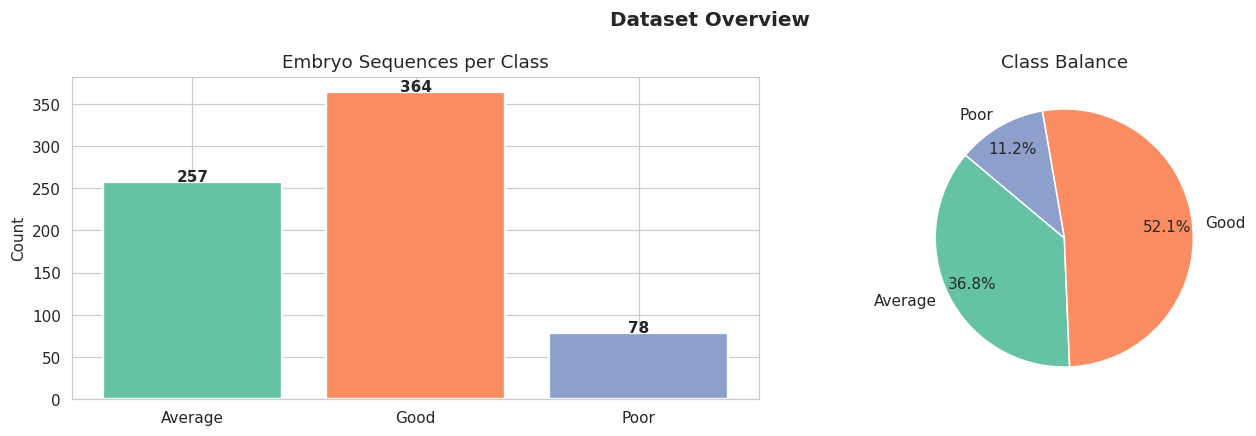

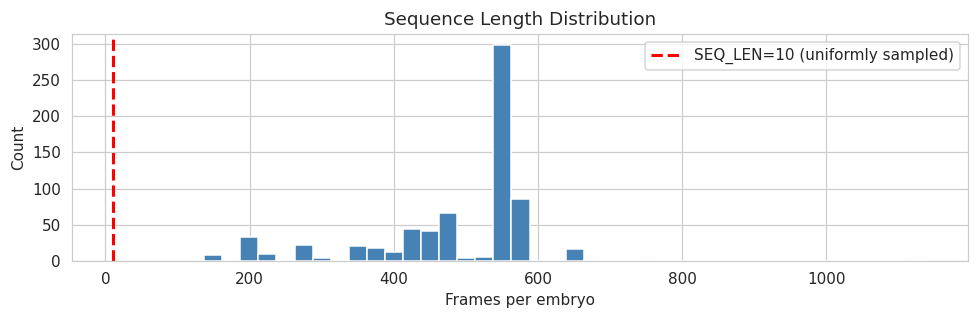

In [54]:
palette = sns.color_palette('Set2', NUM_CLASSES)
counts  = seq_df['label'].value_counts().reindex(CLASS_NAMES, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Dataset Overview', fontsize=13, fontweight='bold')
bars = axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white', lw=1.5)
axes[0].set_title('Embryo Sequences per Class'); axes[0].set_ylabel('Count')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=palette, startangle=140, pctdistance=0.8)
axes[1].set_title('Class Balance')
plt.tight_layout()
plt.savefig(OUT_DIR / 'class_distribution.png', dpi=110, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(seq_df['num_frames'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(cfg.SEQ_LEN, color='red', ls='--', lw=2, label=f'SEQ_LEN={cfg.SEQ_LEN} (uniformly sampled)')
ax.set_xlabel('Frames per embryo'); ax.set_ylabel('Count')
ax.set_title('Sequence Length Distribution'); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'sequence_lengths.png', dpi=110, bbox_inches='tight')
plt.show()

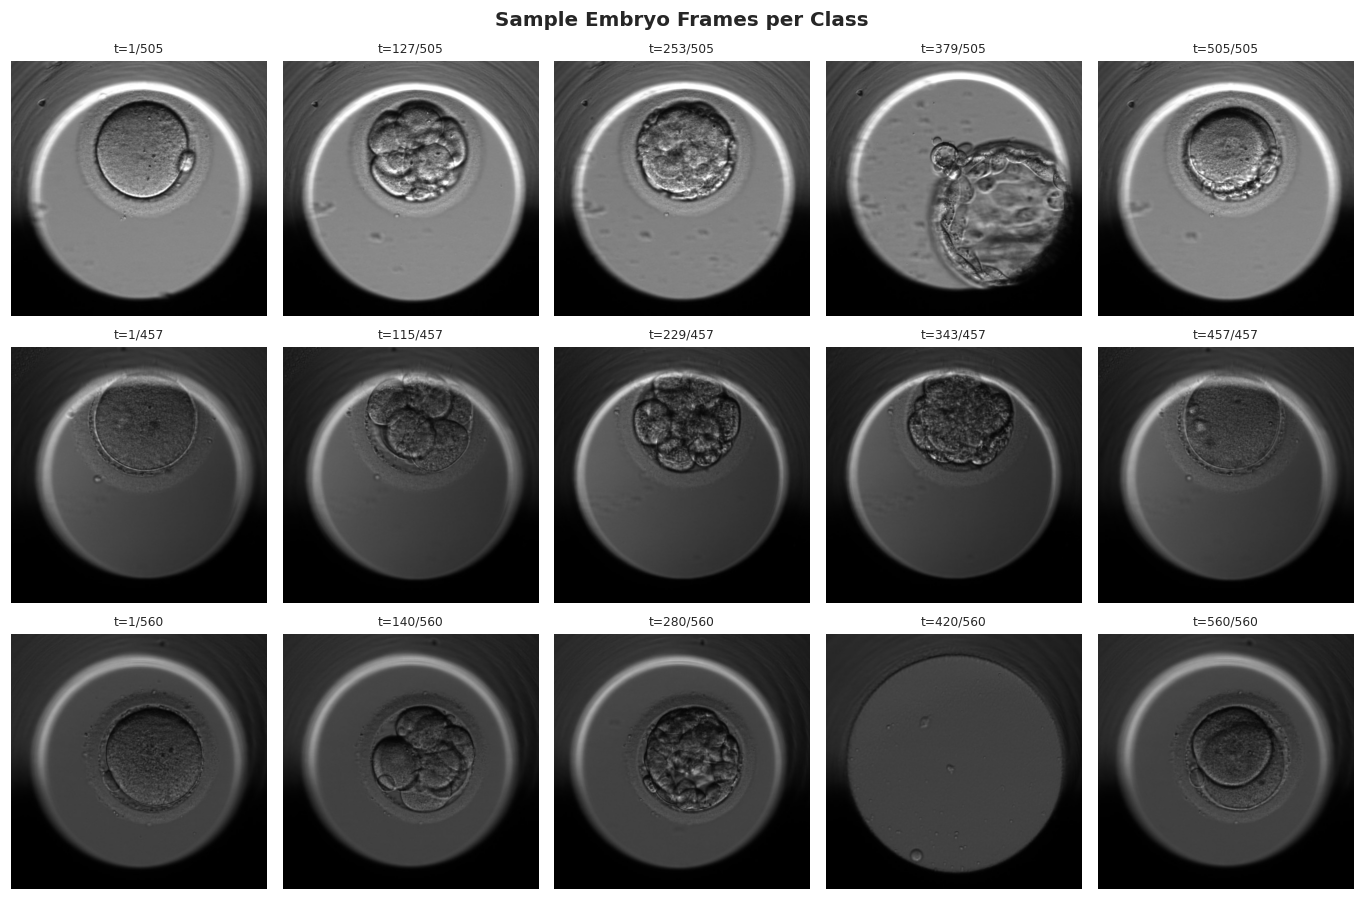

In [55]:
def show_samples(seq_df, class_names, frames_to_show=5):
    n_cls = len(class_names)
    fig, axes = plt.subplots(n_cls, frames_to_show,
                              figsize=(frames_to_show*2.5, n_cls*2.8))
    if n_cls == 1: axes = axes[np.newaxis, :]
    fig.suptitle('Sample Embryo Frames per Class', fontsize=13, fontweight='bold')
    for row, cls in enumerate(class_names):
        sample = seq_df[seq_df['label']==cls].sample(1, random_state=42).iloc[0]
        paths  = sample['filepaths']
        idxs   = np.linspace(0, len(paths)-1, frames_to_show, dtype=int)
        axes[row, 0].set_ylabel(cls, fontsize=11, fontweight='bold',
                                 rotation=0, labelpad=55, va='center')
        for col, idx in enumerate(idxs):
            ax = axes[row, col]
            try:
                ax.imshow(Image.open(paths[idx]).convert('RGB'))
            except Exception as e:
                ax.text(0.5,0.5,str(e),transform=ax.transAxes,ha='center',fontsize=6)
            ax.set_title(f't={idx+1}/{len(paths)}', fontsize=8)
            ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUT_DIR/'sample_frames.png', dpi=110, bbox_inches='tight')
    plt.show()

show_samples(seq_df, CLASS_NAMES)

## 06 · Train/Val/Test Split & DataLoaders

In [56]:
def split3(df, tr, va, seed):
    te = 1.0-tr-va
    trval, test = train_test_split(df, test_size=te, stratify=df['label_idx'], random_state=seed)
    train, val  = train_test_split(trval, test_size=va/(tr+va), stratify=trval['label_idx'], random_state=seed)
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train_df, val_df, test_df = split3(seq_df, cfg.TRAIN_R, cfg.VAL_R, cfg.SEED)
print(f'Split -> Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')
for name, df in [('Train',train_df),('Val',val_df),('Test',test_df)]:
    print(f'  {name}: {df["label"].value_counts().to_dict()}')


def make_tfm(split):
    base = [transforms.Resize(cfg.IMG_SIZE), transforms.ToTensor(),
            transforms.Normalize(cfg.NORM_MEAN, cfg.NORM_STD)]
    if split == 'train':
        return transforms.Compose([
            transforms.Resize(cfg.IMG_SIZE),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.2),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.1, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(cfg.NORM_MEAN, cfg.NORM_STD),
        ])
    return transforms.Compose(base)

train_tfm = make_tfm('train')
eval_tfm  = make_tfm('eval')


def sample_frames(paths, seq_len):
    n = len(paths)
    if n >= seq_len:
        idx = np.linspace(0, n-1, seq_len, dtype=int)
    else:
        idx = list(range(n)) + [n-1]*(seq_len-n)
    return [paths[i] for i in idx]


class EmbryoDataset(Dataset):
    def __init__(self, manifest, transform, seq_len=cfg.SEQ_LEN):
        self.transform = transform
        self.samples = [(sample_frames(list(row.filepaths), seq_len), int(row.label_idx))
                        for row in manifest.itertuples()]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        paths, lbl = self.samples[idx]
        frames = []
        for p in paths:
            try:    img = Image.open(p).convert('RGB')
            except: img = Image.new('RGB', cfg.IMG_SIZE, 0)
            frames.append(self.transform(img))
        return torch.stack(frames), torch.tensor(lbl, dtype=torch.long)


train_ds = EmbryoDataset(train_df, train_tfm)
val_ds   = EmbryoDataset(val_df,   eval_tfm)
test_ds  = EmbryoDataset(test_df,  eval_tfm)
print(f'Dataset sizes -> Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}')

x0, y0 = train_ds[0]
print(f'Frame tensor : {x0.shape}  ->  [T={cfg.SEQ_LEN}, C=3, H, W]')
print(f'Label        : {y0.item()} ({CLASS_NAMES[y0.item()]})')


def make_sampler(ds):
    labels = [s[1] for s in ds.samples]
    counts = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
    w = 1.0 / (counts[labels] + 1e-8)
    return WeightedRandomSampler(torch.DoubleTensor(w), len(w), replacement=True)

NW = 2
train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, sampler=make_sampler(train_ds),
                          num_workers=NW, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg.BATCH_SIZE, shuffle=False,
                          num_workers=NW, pin_memory=True, persistent_workers=True)
print(f'Train batches: {len(train_loader)}')

Split -> Train 489 | Val 105 | Test 105
  Train: {'Good': 255, 'Average': 180, 'Poor': 54}
  Val: {'Good': 54, 'Average': 39, 'Poor': 12}
  Test: {'Good': 55, 'Average': 38, 'Poor': 12}
Dataset sizes -> Train 489 | Val 105 | Test 105
Frame tensor : torch.Size([10, 3, 224, 224])  ->  [T=10, C=3, H, W]
Label        : 0 (Average)
Train batches: 62


## 07 · CNN + LSTM Model

```
Input [B, T=10, 3, 224, 224]
  -> Reshape [B*T, 3, 224, 224]
  -> ResNet18 backbone (weights shared across T) -> [B*T, 512]
  -> Reshape [B, T, 512]
  -> 2-layer LSTM -> [B, T, 256]
  -> Soft temporal attention -> [B, 256]
  -> Dropout -> FC(128) -> GELU -> Dropout -> FC(NUM_CLASSES)
```

In [57]:
class CNNEncoder(nn.Module):
    def __init__(self, backbone='resnet18', pretrained=True, out_dim=512):
        super().__init__()
        base = getattr(models, backbone)(pretrained=pretrained)
        in_f = base.fc.in_features
        self.features = nn.Sequential(*list(base.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Linear(in_f, out_dim) if in_f != out_dim else nn.Identity()
        self.bn   = nn.BatchNorm1d(out_dim)

    def forward(self, x):
        return self.bn(self.proj(self.pool(self.features(x)).flatten(1)))

    def freeze(self):
        for p in self.features.parameters(): p.requires_grad_(False)

    def unfreeze(self):
        for p in self.features.parameters(): p.requires_grad_(True)


class TemporalAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.score = nn.Linear(hidden, 1, bias=False)

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        return (w * x).sum(dim=1)


class EmbryoCNNLSTM(nn.Module):
    def __init__(self, backbone='resnet18', pretrained=True,
                 cnn_dim=512, lstm_hidden=256, lstm_layers=2,
                 lstm_drop=0.3, fc_drop=0.5, num_classes=3):
        super().__init__()
        self.cnn  = CNNEncoder(backbone, pretrained, cnn_dim)
        self.lstm = nn.LSTM(cnn_dim, lstm_hidden, lstm_layers, batch_first=True,
                            dropout=lstm_drop if lstm_layers > 1 else 0.0)
        self.attn = TemporalAttention(lstm_hidden)
        self.head = nn.Sequential(
            nn.Dropout(fc_drop), nn.Linear(lstm_hidden, 128),
            nn.GELU(), nn.Dropout(fc_drop*0.5), nn.Linear(128, num_classes),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        feat = self.cnn(x.view(B*T, C, H, W)).view(B, T, -1)
        out, _ = self.lstm(feat)
        return self.head(self.attn(out))

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


model = EmbryoCNNLSTM(
    backbone=cfg.CNN_BACKBONE, cnn_dim=cfg.CNN_DIM,
    lstm_hidden=cfg.LSTM_HIDDEN, lstm_layers=cfg.LSTM_LAYERS,
    lstm_drop=cfg.LSTM_DROP, fc_drop=cfg.FC_DROP, num_classes=NUM_CLASSES,
).to(cfg.DEVICE)

print(f'Trainable params : {model.n_params():,}')
with torch.no_grad():
    dummy = torch.randn(2, cfg.SEQ_LEN, 3, *cfg.IMG_SIZE).to(cfg.DEVICE)
    out   = model(dummy)
    print(f'Forward pass     : {list(dummy.shape)} -> {list(out.shape)}  OK')

Trainable params : 12,525,891
Forward pass     : [2, 10, 3, 224, 224] -> [2, 3]  OK


## 08 · Training Loop

In [58]:
def class_weights(df, n_cls, device):
    counts = np.bincount(df['label_idx'].values, minlength=n_cls).astype(float)
    w = 1.0 / (counts + 1e-8)
    return torch.FloatTensor(w / w.sum() * n_cls).to(device)

cw        = class_weights(train_df, NUM_CLASSES, cfg.DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6
)
print(f'Class weights : {cw.cpu().numpy().round(3)}')


class EarlyStopping:
    def __init__(self, patience, delta, path):
        self.patience=patience; self.delta=delta; self.path=path
        self.counter=0; self.best=float('inf'); self.triggered=False

    def step(self, val_loss, model):
        if val_loss < self.best - self.delta:
            self.best=val_loss; self.counter=0
            torch.save(model.state_dict(), self.path)
            return 'saved'
        self.counter += 1
        if self.counter >= self.patience:
            self.triggered=True; return 'STOP'
        return f'patience {self.counter}/{self.patience}'

stopper = EarlyStopping(cfg.ES_PATIENCE, cfg.ES_DELTA, CKPT_DIR/'best_model.pt')


def run_epoch(model, loader, criterion, optimizer, device, grad_clip, training):
    model.train() if training else model.eval()
    total_loss=total_correct=total_n=0
    all_preds=[]; all_labels=[]
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for frames, labels in loader:
            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(frames)
            loss   = criterion(logits, labels)
            if training:
                optimizer.zero_grad(); loss.backward()
                if grad_clip: nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            preds = logits.argmax(1)
            total_loss    += loss.item()*len(labels)
            total_correct += (preds==labels).sum().item()
            total_n       += len(labels)
            all_preds .extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/total_n, total_correct/total_n, np.array(all_preds), np.array(all_labels)

print('Training setup complete.')

Class weights : [0.595 0.42  1.984]
Training setup complete.


In [59]:
history = defaultdict(list)
print(f"{'Ep':>4} | {'TrLoss':>7} | {'TrAcc':>6} | {'VaLoss':>7} | {'VaAcc':>6} | {'LR':>8} | Status")
print('─'*70)

for epoch in range(1, cfg.NUM_EPOCHS+1):
    if epoch == 1:
        model.cnn.freeze()
    elif epoch == cfg.FREEZE_EPOCHS+1:
        model.cnn.unfreeze()
        print(f'  CNN unfrozen at epoch {epoch}')

    tr_loss,tr_acc,_,_ = run_epoch(model, train_loader, criterion, optimizer, cfg.DEVICE, cfg.GRAD_CLIP, True)
    va_loss,va_acc,_,_ = run_epoch(model, val_loader,   criterion, None,      cfg.DEVICE, None,          False)
    scheduler.step(va_loss)
    lr     = optimizer.param_groups[0]['lr']
    status = stopper.step(va_loss, model)

    history['tr_loss'].append(tr_loss); history['tr_acc'].append(tr_acc)
    history['va_loss'].append(va_loss); history['va_acc'].append(va_acc)
    history['lr']     .append(lr)

    mark = 'saved' if status=='saved' else ('STOP' if status=='STOP' else status)
    print(f'{epoch:4d} | {tr_loss:7.4f} | {tr_acc*100:5.1f}% | '
          f'{va_loss:7.4f} | {va_acc*100:5.1f}% | {lr:.2e} | {mark}')
    if stopper.triggered:
        print(f'Early stopping at epoch {epoch}'); break

print(f'Best val loss: {stopper.best:.4f}')

  Ep |  TrLoss |  TrAcc |  VaLoss |  VaAcc |       LR | Status
──────────────────────────────────────────────────────────────────────
   1 |  1.0576 |  35.2% |  1.2158 |  11.4% | 3.00e-04 | saved
   2 |  0.8375 |  35.2% |  1.3146 |  12.4% | 3.00e-04 | patience 1/8
   3 |  0.7454 |  44.4% |  1.9898 |  11.4% | 3.00e-04 | patience 2/8
   4 |  0.6363 |  52.8% |  1.3263 |  29.5% | 3.00e-04 | patience 3/8
   5 |  0.6346 |  57.9% |  1.6031 |  23.8% | 3.00e-04 | patience 4/8
  CNN unfrozen at epoch 6
   6 |  1.3158 |  37.2% |  1.3288 |  19.0% | 1.50e-04 | patience 5/8
   7 |  0.9289 |  38.7% |  1.3036 |  15.2% | 1.50e-04 | patience 6/8
   8 |  0.8358 |  44.0% |  1.1096 |  33.3% | 1.50e-04 | saved
   9 |  0.7109 |  49.9% |  1.5636 |  27.6% | 1.50e-04 | patience 1/8
  10 |  0.6996 |  57.1% |  1.1055 |  45.7% | 1.50e-04 | saved
  11 |  0.6089 |  64.0% |  2.1379 |  31.4% | 1.50e-04 | patience 1/8
  12 |  0.5613 |  73.0% |  1.1606 |  59.0% | 1.50e-04 | patience 2/8
  13 |  0.4736 |  80.8% |  0.9211

## 09 · Training Curves

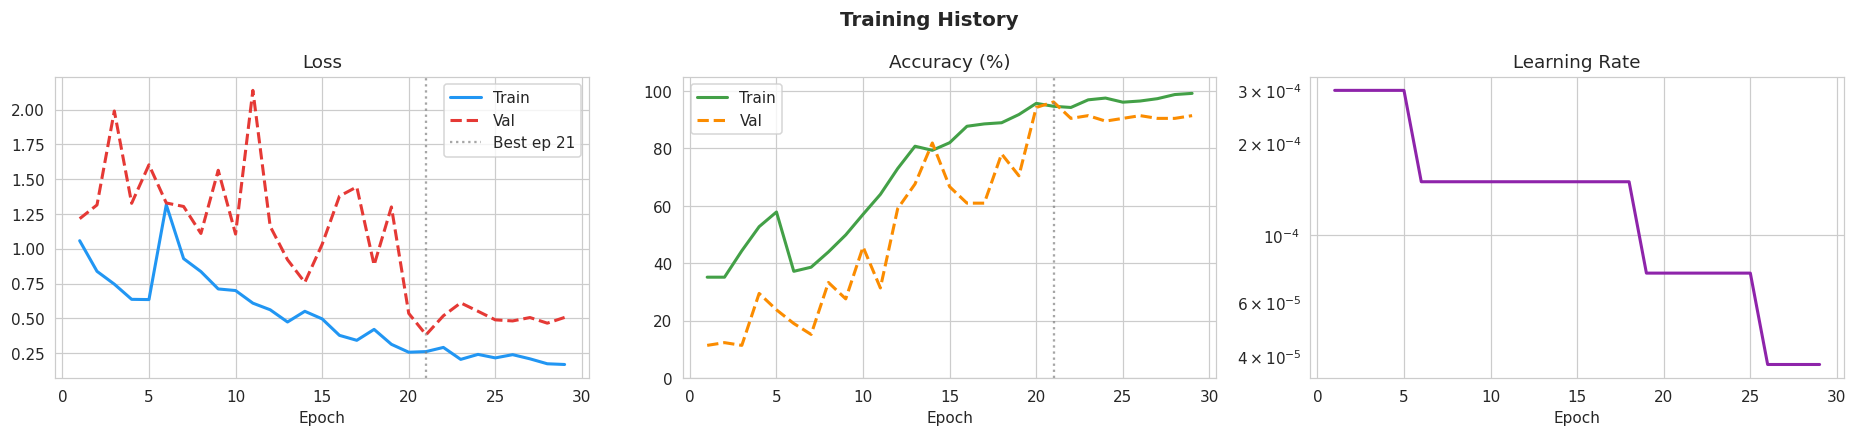

In [60]:
ep      = range(1, len(history['tr_loss'])+1)
best_ep = int(np.argmin(history['va_loss']))+1

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

axes[0].plot(ep, history['tr_loss'], label='Train', color='#2196F3', lw=2)
axes[0].plot(ep, history['va_loss'], label='Val',   color='#E53935', lw=2, ls='--')
axes[0].axvline(best_ep, color='gray', ls=':', alpha=.7, label=f'Best ep {best_ep}')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, [a*100 for a in history['tr_acc']], label='Train', color='#43A047', lw=2)
axes[1].plot(ep, [a*100 for a in history['va_acc']], label='Val',   color='#FB8C00', lw=2, ls='--')
axes[1].axvline(best_ep, color='gray', ls=':', alpha=.7)
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim([0, 105]); axes[1].legend()

axes[2].semilogy(ep, history['lr'], color='#8E24AA', lw=2)
axes[2].set_title('Learning Rate'); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(OUT_DIR/'training_curves.png', dpi=110, bbox_inches='tight')
plt.show()

## 10 · Test Evaluation

In [61]:
model.load_state_dict(torch.load(CKPT_DIR/'best_model.pt', map_location=cfg.DEVICE))
print('Best checkpoint loaded.')

te_loss,te_acc,te_preds,te_labels = run_epoch(
    model, test_loader, criterion, None, cfg.DEVICE, None, False
)
prec = precision_score(te_labels, te_preds, average='weighted', zero_division=0)
rec  = recall_score   (te_labels, te_preds, average='weighted', zero_division=0)
f1   = f1_score       (te_labels, te_preds, average='weighted', zero_division=0)

print('='*46)
print('  TEST SET RESULTS')
print('='*46)
print(f'  Accuracy  : {te_acc*100:.2f}%')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec :.4f}  (weighted)')
print(f'  F1-Score  : {f1  :.4f}  (weighted)')
print('='*46)
print()
print(classification_report(te_labels, te_preds, target_names=CLASS_NAMES, zero_division=0))

metrics = dict(accuracy=round(te_acc,4), precision=round(prec,4),
               recall=round(rec,4), f1=round(f1,4))
with open(OUT_DIR/'test_metrics.json','w') as f:
    json.dump(metrics, f, indent=2)
print(f'Saved -> {OUT_DIR}/test_metrics.json')

Best checkpoint loaded.
  TEST SET RESULTS
  Accuracy  : 92.38%
  Precision : 0.9267  (weighted)
  Recall    : 0.9238  (weighted)
  F1-Score  : 0.9230  (weighted)

              precision    recall  f1-score   support

     Average       0.88      0.92      0.90        38
        Good       0.95      0.96      0.95        55
        Poor       1.00      0.75      0.86        12

    accuracy                           0.92       105
   macro avg       0.94      0.88      0.90       105
weighted avg       0.93      0.92      0.92       105

Saved -> /kaggle/working/outputs/test_metrics.json


## 11 · Confusion Matrix

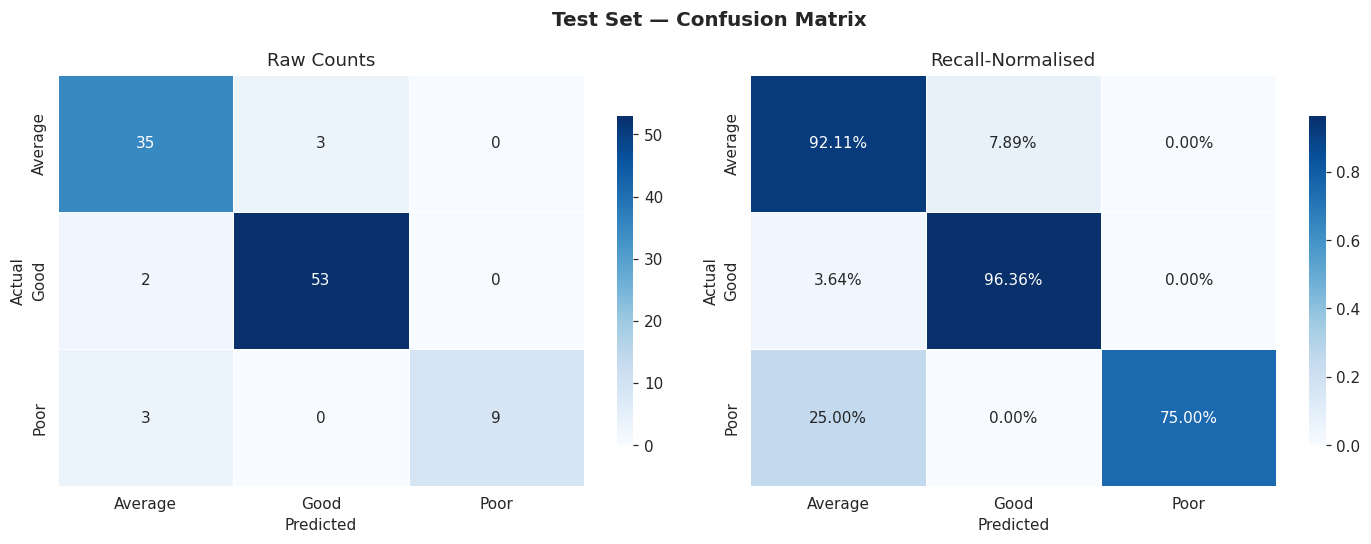

In [62]:
cm      = confusion_matrix(te_labels, te_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Test Set — Confusion Matrix', fontsize=13, fontweight='bold')
for ax, data, title, fmt in zip(axes, [cm, cm_norm],
                                 ['Raw Counts','Recall-Normalised'], ['d','.2%']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(OUT_DIR/'confusion_matrix.png', dpi=110, bbox_inches='tight')
plt.show()

## 12 · Prediction Examples

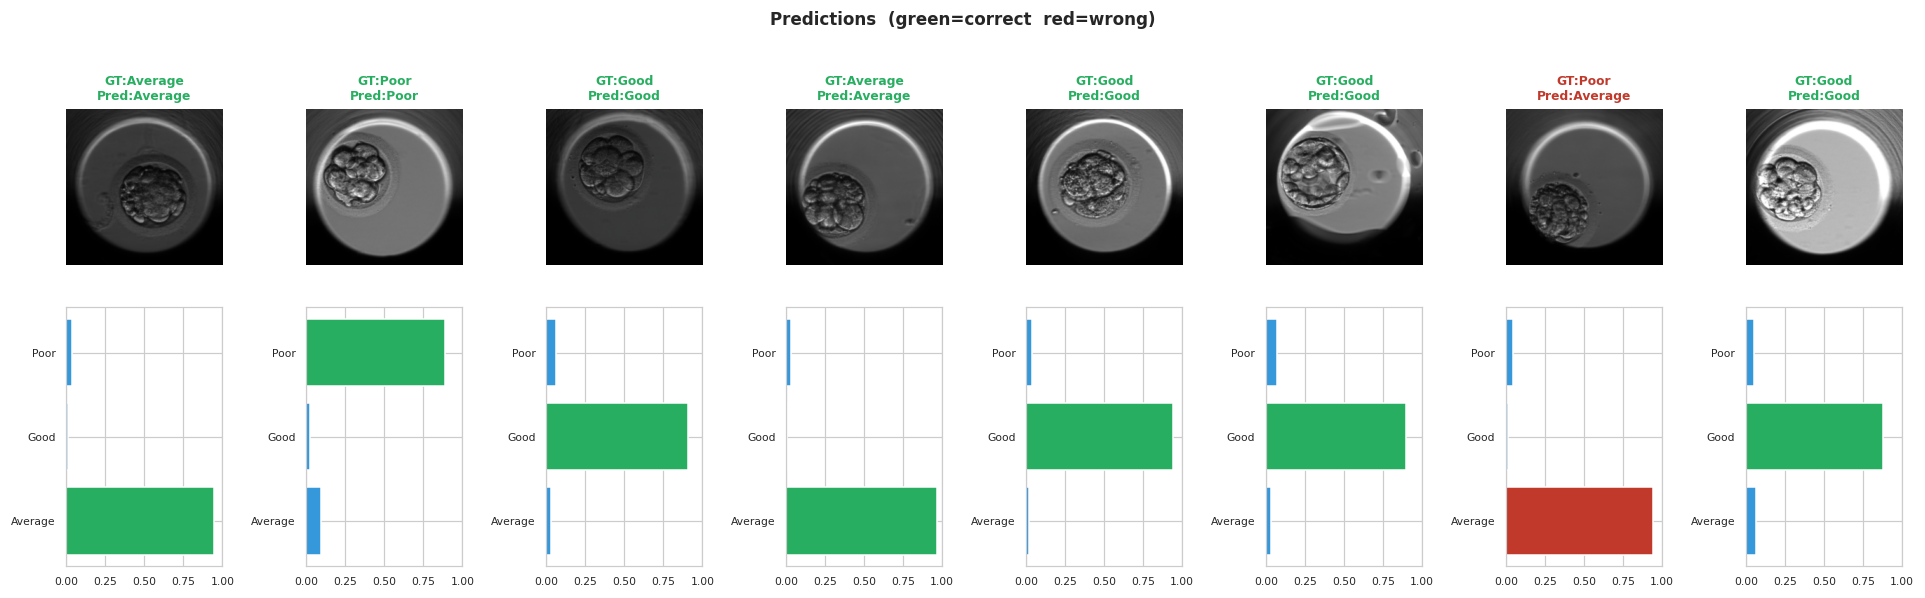

In [63]:
def denorm(t):
    m = torch.tensor(cfg.NORM_MEAN).view(3,1,1)
    s = torch.tensor(cfg.NORM_STD ).view(3,1,1)
    return (t*s+m).clamp(0,1)

@torch.no_grad()
def show_predictions(model, loader, class_names, device, n=8):
    model.eval()
    frames_b, labels_b = next(iter(loader))
    n = min(n, len(frames_b))
    logits = model(frames_b.to(device))
    probs  = torch.softmax(logits,1).cpu().numpy()
    preds  = probs.argmax(1)
    mid    = frames_b.shape[1]//2

    fig, axes = plt.subplots(2, n, figsize=(n*2.2, 5.5))
    fig.suptitle('Predictions  (green=correct  red=wrong)', fontsize=11, fontweight='bold')
    for i in range(n):
        gt = labels_b[i].item(); pred = preds[i]
        color = '#27ae60' if gt==pred else '#c0392b'
        axes[0,i].imshow(denorm(frames_b[i,mid]).permute(1,2,0).numpy())
        axes[0,i].axis('off')
        axes[0,i].set_title(f'GT:{class_names[gt]}\nPred:{class_names[pred]}',
                             fontsize=8, color=color, fontweight='bold')
        cols = ['#3498db']*len(class_names); cols[pred]=color
        axes[1,i].barh(class_names, probs[i], color=cols)
        axes[1,i].set_xlim(0,1); axes[1,i].tick_params(labelsize=7)
    plt.tight_layout()
    plt.savefig(OUT_DIR/'predictions.png', dpi=110, bbox_inches='tight')
    plt.show()

show_predictions(model, test_loader, CLASS_NAMES, cfg.DEVICE)

## 13 · Export & Final Summary

In [64]:
torch.save({
    'model_state'    : model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'history'        : dict(history),
    'metrics'        : metrics,
    'config': dict(class_names=CLASS_NAMES, num_classes=NUM_CLASSES,
                   seq_len=cfg.SEQ_LEN, img_size=cfg.IMG_SIZE,
                   backbone=cfg.CNN_BACKBONE),
}, CKPT_DIR/'full_checkpoint.pt')
print(f'Full checkpoint saved.')


@torch.no_grad()
def predict_embryo(image_paths, model, transform, seq_len, class_names, device):
    model.eval()
    frames = []
    for p in sample_frames(list(image_paths), seq_len):
        try:    img = Image.open(p).convert('RGB')
        except: img = Image.new('RGB', cfg.IMG_SIZE, 0)
        frames.append(transform(img))
    seq   = torch.stack(frames).unsqueeze(0).to(device)
    probs = torch.softmax(model(seq),1)[0].cpu().numpy()
    idx   = probs.argmax()
    return {'predicted_class': class_names[idx],
            'confidence'     : float(probs[idx]),
            'probabilities'  : {c: float(p) for c,p in zip(class_names,probs)}}


# Demo inference
row    = test_df.sample(1, random_state=0).iloc[0]
result = predict_embryo(row['filepaths'], model, eval_tfm,
                         cfg.SEQ_LEN, CLASS_NAMES, cfg.DEVICE)
print(f"Embryo : {row['embryo_id']}")
print(f"GT     : {row['label']}")
print(f"Pred   : {result['predicted_class']}  ({result['confidence']:.1%})")
print(f"Probs  : {result['probabilities']}")

print('\n' + '='*50)
print('  PIPELINE SUMMARY')
print('='*50)
print(f'  Dataset     : abhishekbuddiga06/embryo-dataset')
print(f'  Embryos     : {len(seq_df)}')
print(f'  Classes ({NUM_CLASSES})  : {CLASS_NAMES}')
print(f'  Seq length  : {cfg.SEQ_LEN} frames')
print(f'  Model params: {model.n_params():,}')
print(f'  Epochs      : {len(history["tr_loss"])}')
print(f'  Test acc    : {te_acc*100:.2f}%')
print(f'  Test F1     : {f1:.4f}  (weighted)')
print('='*50)
print('\nSaved files:')
for f in sorted(list(OUT_DIR.glob('*'))+list(CKPT_DIR.glob('*'))):
    print(f'  {str(f):<58}  {f.stat().st_size/1024:.0f} KB')

Full checkpoint saved.
Embryo : TN359-9
GT     : Poor
Pred   : Poor  (99.7%)
Probs  : {'Average': 0.0018794239731505513, 'Good': 0.001604278921149671, 'Poor': 0.996516227722168}

  PIPELINE SUMMARY
  Dataset     : abhishekbuddiga06/embryo-dataset
  Embryos     : 699
  Classes (3)  : ['Average', 'Good', 'Poor']
  Seq length  : 10 frames
  Model params: 12,525,891
  Epochs      : 29
  Test acc    : 92.38%
  Test F1     : 0.9230  (weighted)

Saved files:
  /kaggle/working/checkpoints/best_model.pt                   49016 KB
  /kaggle/working/checkpoints/full_checkpoint.pt              146941 KB
  /kaggle/working/outputs/class_distribution.png              45 KB
  /kaggle/working/outputs/confusion_matrix.png                48 KB
  /kaggle/working/outputs/predictions.png                     190 KB
  /kaggle/working/outputs/sample_frames.png                   606 KB
  /kaggle/working/outputs/sequence_lengths.png                25 KB
  /kaggle/working/outputs/test_metrics.json                